
### **Deep Learning — Entrenamiento, Fine-Tuning y Comparación de Modelos**

En este trabajo se desarrolla un estudio práctico de técnicas de Deep Learning aplicadas a la clasificación de imágenes utilizando el dataset CIFAR-10. Primero se entrena una red neuronal convolucional (CNN) construida desde cero para establecer una línea base de rendimiento. Posteriormente, se implementa *transfer learning* mediante el fine-tuning de dos arquitecturas ampliamente utilizadas en visión por computadora: ResNet50 y MobileNetV2, aprovechando sus pesos preentrenados en ImageNet y adaptándolos al problema de clasificación de 10 clases. Además, se emplea un pipeline eficiente con `tf.data` para realizar el preprocesamiento de imágenes de manera dinámica, optimizando el uso de memoria en Google Colab. Finalmente, se analizan métricas de desempeño, se generan visualizaciones comparativas y se realizan predicciones de ejemplo, permitiendo evaluar la diferencia entre entrenar modelos desde cero y utilizar modelos preentrenados.





### **1. Instalación y carga de librerías**

En esta sección se instalan las dependencias necesarias y se importan las librerías principales del proyecto, incluyendo TensorFlow para construir y entrenar las redes neuronales, Matplotlib para generar visualizaciones y Scikit-learn para utilidades como validación cruzada. Este bloque configura el entorno de ejecución y garantiza que Colab tenga todas las herramientas necesarias para trabajar con modelos de Deep Learning.

---



















In [1]:
!pip install tensorflow matplotlib scikit-learn
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import KFold

from tensorflow.keras import layers, models
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.applications import ResNet50, MobileNetV2


### **2. Carga y preparación del dataset CIFAR-10**

Aquí se carga el conjunto de datos CIFAR-10, un dataset estándar compuesto por 60.000 imágenes distribuidas en 10 clases diferentes. Se separan los datos en conjuntos de entrenamiento y prueba, y se realizan transformaciones básicas como aplastar las etiquetas a un vector unidimensional. Esta sección deja listo el dataset para ser utilizado por los modelos.

---

In [2]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()

y_train = y_train.flatten()
y_test = y_test.flatten()

num_classes = 10


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step



### **3. Creación del pipeline de datos con `tf.data` (preprocesamiento eficiente)**

En este apartado se construye un pipeline con la API `tf.data` que permite procesar las imágenes de forma eficiente sin consumir demasiada memoria. En lugar de redimensionar todas las imágenes de una sola vez —lo que saturaría la RAM de Colab— se aplica un preprocesamiento “on-the-fly”, redimensionando y normalizando cada lote justo antes de enviarlo al modelo. Esto mejora la escalabilidad, acelera el entrenamiento y evita problemas de memoria.

---

In [3]:
IMG_SIZE = 224
BATCH_SIZE = 32

def preprocess(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = preprocess_input(image)
    return image, label

train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train_ds = train_ds.shuffle(10000).map(preprocess).batch(BATCH_SIZE).prefetch(1)

val_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test))
val_ds = val_ds.map(preprocess).batch(BATCH_SIZE).prefetch(1)


### **4. Construcción y entrenamiento de una CNN desde cero**

Se define una red neuronal convolucional simple creada completamente desde cero, sin usar modelos preentrenados. Esta CNN incluye capas de convolución, max pooling, y capas densas finales para la clasificación. Su entrenamiento sirve como línea base para comparar con los modelos preentrenados posteriores, mostrando qué tan bien puede desempeñarse un modelo hecho manualmente con arquitectura sencilla.

---

In [4]:
def create_cnn():
    model = models.Sequential([
        layers.Conv2D(32, (3,3), activation="relu", input_shape=(32,32,3)),
        layers.MaxPooling2D(),
        layers.Conv2D(64, (3,3), activation="relu"),
        layers.MaxPooling2D(),
        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dense(num_classes, activation="softmax")
    ])

    model.compile(optimizer="adam",
                  loss="sparse_categorical_crossentropy",
                  metrics=["accuracy"])
    return model


In [5]:
cnn_model = create_cnn()
history_cnn = cnn_model.fit(X_train, y_train, epochs=5, validation_split=0.2)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.2306 - loss: 7.9175 - val_accuracy: 0.4131 - val_loss: 1.6396
Epoch 2/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.4570 - loss: 1.5091 - val_accuracy: 0.5054 - val_loss: 1.3871
Epoch 3/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.5454 - loss: 1.2820 - val_accuracy: 0.5740 - val_loss: 1.2379
Epoch 4/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6094 - loss: 1.1168 - val_accuracy: 0.5887 - val_loss: 1.1971
Epoch 5/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6632 - loss: 0.9781 - val_accuracy: 0.6075 - val_loss: 1.1850


### **5. Fine-tuning con ResNet50**

En esta parte se utiliza ResNet50, un modelo muy reconocido preentrenado con el enorme dataset ImageNet. Se cargan sus capas convolucionales sin la parte clasificadora y se añaden capas densas finales adaptadas a las 10 clases del CIFAR-10. Las capas del modelo base se congelan para que no se entrenen de nuevo, de modo que se aprovechen sus representaciones aprendidas. Esta técnica, llamada *transfer learning*, ofrece un rendimiento significativamente superior al modelo desde cero.

---

In [6]:
base_resnet = ResNet50(weights="imagenet", include_top=False, pooling="avg")

# congelar capas
base_resnet.trainable = False

model_resnet = models.Sequential([
    base_resnet,
    layers.Dense(128, activation="relu"),
    layers.Dense(num_classes, activation="softmax")
])

model_resnet.compile(optimizer="adam",
                     loss="sparse_categorical_crossentropy",
                     metrics=["accuracy"])

history_resnet = model_resnet.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 177s 105ms/step - accuracy: 0.8350 - loss: 0.4931 - val_accuracy: 0.8962 - val_loss: 0.3148
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 168s 108ms/step - accuracy: 0.9074 - loss: 0.2642 - val_accuracy: 0.8885 - val_loss: 0.3386
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 152s 97ms/step - accuracy: 0.9197 - loss: 0.2273 - val_accuracy: 0.8996 - val_loss: 0.3084
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 152s 97ms/step - accuracy: 0.9297 - loss: 0.1958 - val_accuracy: 0.9064 - val_loss: 0.2883
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 152s 97ms/step - accuracy: 0.9409 - loss: 0.1663 - val_accuracy: 0.9039 - val_loss: 0.3136


### **6. Fine-tuning con MobileNetV2**

Aquí se entrena un segundo modelo preentrenado, MobileNetV2, conocido por ser más ligero y eficiente que ResNet50. El proceso es similar: se reutilizan las características aprendidas por el modelo y se entrena únicamente la parte final. MobileNetV2 es ideal para dispositivos móviles o contextos con recursos limitados, y permite comparar rendimiento y eficiencia entre distintos modelos preentrenados.

---

In [7]:
base_mob = MobileNetV2(weights="imagenet", include_top=False, pooling="avg")
base_mob.trainable = False

model_mobile = models.Sequential([
    base_mob,
    layers.Dense(128, activation="relu"),
    layers.Dense(num_classes, activation="softmax")
])

model_mobile.compile(optimizer="adam",
                     loss="sparse_categorical_crossentropy",
                     metrics=["accuracy"])

history_mobile = model_mobile.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)


/tmp/ipython-input-3737160723.py:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_mob = MobileNetV2(weights="imagenet", include_top=False, pooling="avg")


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 159s 90ms/step - accuracy: 0.4910 - loss: 1.4406 - val_accuracy: 0.5965 - val_loss: 1.1496
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 169s 78ms/step - accuracy: 0.6030 - loss: 1.1288 - val_accuracy: 0.6113 - val_loss: 1.1067
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 123s 79ms/step - accuracy: 0.6271 - loss: 1.0600 - val_accuracy: 0.6121 - val_loss: 1.0981
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 142s 79ms/step - accuracy: 0.6451 - loss: 1.0113 - val_accuracy: 0.6196 - val_loss: 1.0920
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 140s 78ms/step - accuracy: 0.6582 - loss: 0.9678 - val_accuracy: 0.6294 - val_loss: 1.0673


### **7. Visualización de curvas de entrenamiento**

Esta sección presenta gráficas que muestran la evolución de la precisión en entrenamiento y validación a lo largo de las épocas. Estas visualizaciones permiten identificar si un modelo está aprendiendo adecuadamente, si está sobreajustando y cómo se comparan entre sí los distintos enfoques (CNN desde cero, ResNet50 y MobileNetV2). Son fundamentales para interpretar los resultados del entrenamiento.

---

In [8]:
def plot_history(history, title):
    plt.plot(history.history["accuracy"], label="train")
    plt.plot(history.history["val_accuracy"], label="val")
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()


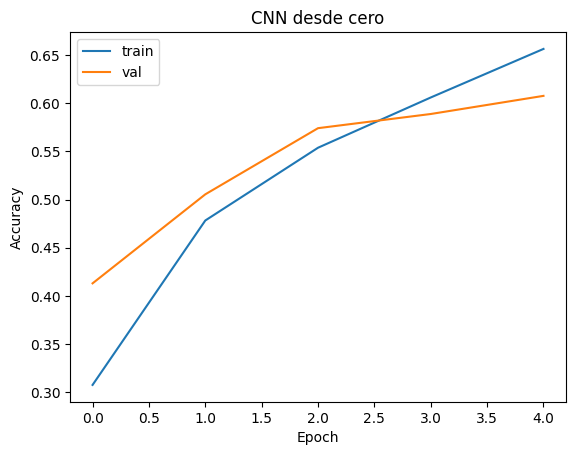

In [12]:
plot_history(history_cnn, "CNN desde cero")




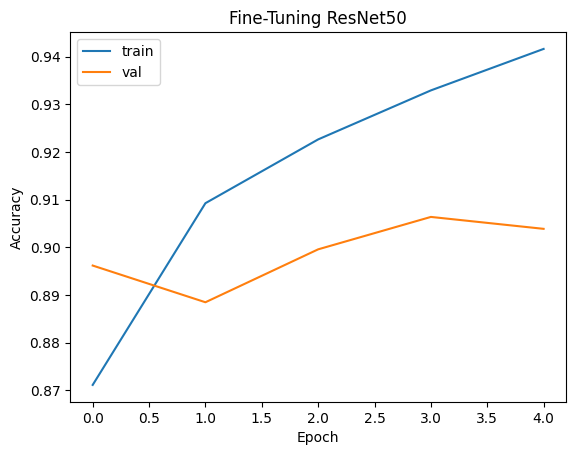

In [13]:
plot_history(history_resnet, "Fine-Tuning ResNet50")

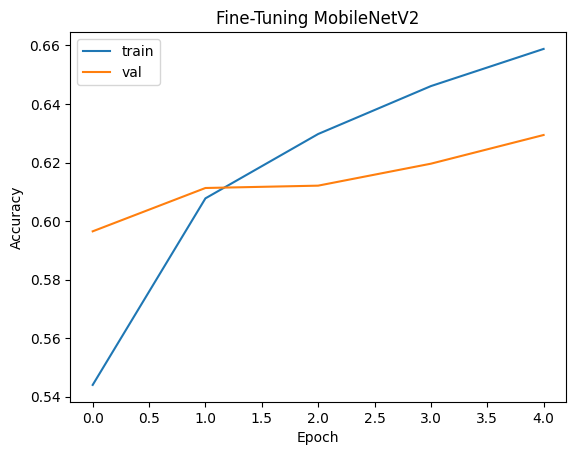

In [14]:
plot_history(history_mobile, "Fine-Tuning MobileNetV2")

### **8. Evaluación final de los modelos**

Aquí se evalúa cada modelo sobre el conjunto de prueba o sobre el dataset de validación, calculando la precisión final. Esta comparación cuantitativa permite identificar cuál enfoque ofrece el mejor rendimiento real y verificar la mejora obtenida mediante fine-tuning de modelos preentrenados.

---

In [10]:
print("CNN desde cero:", cnn_model.evaluate(X_test, y_test)[1])
print("ResNet50:", model_resnet.evaluate(val_ds)[1])
print("MobileNetV2:", model_mobile.evaluate(val_ds)[1])


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6054 - loss: 1.1870
CNN desde cero: 0.6021999716758728
313/313 ━━━━━━━━━━━━━━━━━━━━ 25s 80ms/step - accuracy: 0.9003 - loss: 0.3122
ResNet50: 0.9039000272750854
313/313 ━━━━━━━━━━━━━━━━━━━━ 20s 64ms/step - accuracy: 0.6225 - loss: 1.0788
MobileNetV2: 0.6294000148773193


### **9. Predicciones de ejemplo con los modelos entrenados**

En esta última parte se selecciona una imagen de prueba al azar y se muestran las predicciones realizadas por los modelos preentrenados, comparándolas con la etiqueta real. Esta evaluación cualitativa ayuda a interpretar cómo toman decisiones los modelos y brinda una comprensión visual de su desempeño.

---

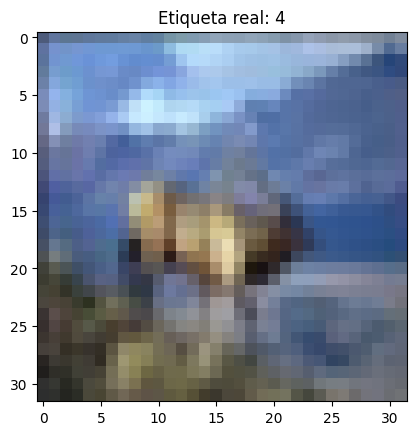

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
ResNet50 pred: 4
1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step
MobileNet pred: 9


In [11]:
import random

i = random.randint(0, len(X_test)-1)
plt.imshow(X_test[i])
plt.title(f"Etiqueta real: {y_test[i]}")
plt.show()

img_resized = tf.image.resize(X_test[i], (IMG_SIZE, IMG_SIZE))
img_resized = preprocess_input(img_resized)
img_resized = tf.expand_dims(img_resized, 0)

print("ResNet50 pred:", np.argmax(model_resnet.predict(img_resized)))
print("MobileNet pred:", np.argmax(model_mobile.predict(img_resized)))
